# Parsing
The {class}`~sfsutils.parser.Parser` reads a VCF file and counts derived-allele frequencies into a site-frequency spectrum. For a sample of `n` haplotypes it returns counts in bins `0, 1, ..., n`, projecting down when more haplotypes are present. Polarisation relies on the ancestral allele: by default the `AA` info field is consulted, and sites where it is undefined are skipped (see {attr}`~sfsutils.parser.Parser.skip_non_polarized`). When no ancestral state is available the spectrum can instead be folded, at the cost of conflating minor and major allele counts.

A single spectrum is rarely enough on its own. More often we want to separate sites into classes that behave differently and read off one spectrum per class. This is expressed by passing stratifications to the parser. The example below contrasts 0-fold and 4-fold degenerate sites using a VCF for `Betula spp.`

In [1]:
import matplotlib.pyplot as plt
from sfsutils.settings import Settings

plt.rcParams['figure.figsize'] = [4.4, 3.3]
Settings.disable_pbar = True

In [2]:
import sfsutils as su

In [3]:
# instantiate parser
p = su.Parser(
    n=8,
    source="resources/genome/betula/biallelic.polarized.subset.10000.vcf.gz",
    fasta="resources/genome/betula/genome.subset.20.fasta",
    gff="resources/genome/betula/genome.gff.gz",
    annotations=[
        su.DegeneracyAnnotation()
    ],
    stratifications=[su.DegeneracyStratification()]
)

# parse SFS
spectra: su.Spectra = p.parse()

INFO:Parser: Using stratification: [neutral, selected].
INFO:Parser: Loading VCF file
INFO:Parser: Loading GFF file
INFO:sfsutils: Unzipping resources/genome/betula/genome.gff.gz to /var/folders/n4/m5q2jgw91zv0tp1c4j9bh48m0000gn/T/tmpe7o10srq.gff
INFO:Parser: Loading FASTA file


INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:DegeneracyStratification: Number of sites with valid type: 2538
INFO:DegeneracyAnnotation: Annotated 3494 sites.
INFO:Parser: Skipped 401 sites without ancestral allele information.
INFO:Parser: Included 2538 out of 10000 sites in total from the VCF file.


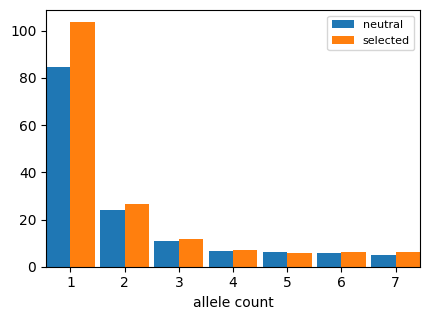

In [4]:
# visualize SFS
spectra.plot();

`sfsutils` relies here on VCF info tags to determine the degeneracy of a site but this behavior can be customized (cf. {class}`~sfsutils.parser.DegeneracyStratification`).